# 개인 솔로랭크 데이터 기반 챔피언 선택 분석

Riot API로 수집한 개인 경기 기록에서 **내 챔피언 선택과 아군·적군 구성에 따른 승률 차이**를 탐색한다.

## 1. 문제 정의

1. **내 픽:** 포지션별로 어떤 챔피언을 선택했을 때 승률이 높은가?
2. **상대:** 어떤 상대 챔피언을 만났을 때 승률이 낮은가?
3. **아군 조합:** 내 챔피언과 어떤 아군 정글이 함께할 때 승률이 높은가?

목적은 개인의 챔피언 선택과 복기 대상을 찾는 것이다. 전체 이용자의 챔피언 티어 또는 인과적인 카운터 관계를 추정하지 않는다.

### 데이터와 분석 단위
- 출처: [Riot Match-V5](https://developer.riotgames.com/apis/#match-v5), 프로젝트 수집 코드 `main.py`
- 입력: `data/processed/my_lol_games.csv`, **한 행은 본인의 한 경기**
- 모집단: 수집된 개인 솔로랭크(개인/2인 랭크, queue 420) 기록
- 승률 = 승리 경기 수 / 분석 대상 경기 수
- 아래 실행 결과에 수집 기간·패치·제외 건수를 명시한다. 원본 날짜는 UTC이며 분석 시 한국 시간(Asia/Seoul)으로 변환한다.

### 분석 전에 정한 기준
- 중복 경기 ID는 첫 행만 유지한다. 승패·날짜·게임 시간·본인 포지션이 유효한 솔로랭크만 사용한다.
- **3분 미만 경기 제외**: 다시하기 필드가 없어 사용하는 대리 기준이다. 정확한 다시하기 분류가 아니므로 포함/제외 시 전체 승률도 비교한다.
- **10경기 이상**을 주요 비교 대상으로 통일한다. 미만 그룹은 참고 자료로 분리한다.
- 각 그룹의 경기 수, 승률, 95% Wilson 신뢰구간을 함께 표시한다. 신뢰구간은 경기들이 독립이고 승리 확률이 일정하다는 근사 가정에 따른다.
- 많은 그룹을 탐색하므로 높은 순위나 낮은 순위를 통계적으로 확정된 차이로 해석하지 않는다.


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display, Markdown

MIN_GAMES = 10
MIN_DURATION = 3.0
POSITIONS = ['TOP', 'JUNGLE', 'MIDDLE', 'BOTTOM', 'UTILITY']
ROOT = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
DATA_PATH = ROOT / 'data' / 'processed' / 'my_lol_games.csv'
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 30)
fonts = {f.name for f in font_manager.fontManager.ttflist}
for font in ['Malgun Gothic', 'AppleGothic', 'NanumGothic']:
    if font in fonts:
        plt.rcParams['font.family'] = font
        break
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110
print(f'Python {sys.version.split()[0]} | pandas {pd.__version__}')
raw = pd.read_csv(DATA_PATH)
print(f'원본: {len(raw):,}경기 / {raw.shape[1]}개 열')


Python 3.14.3 | pandas 3.0.2
원본: 500경기 / 42개 열


## 2. 데이터 품질 검증과 전처리

원본 CSV는 변경하지 않는다. 경기 제외와 조합 분석에 필요한 포지션 누락을 구분한다. 아군 번호는 고정 포지션이 아니므로 반드시 각 슬롯의 `position`을 확인한다.

In [2]:
required = ['match_id', 'queue_id', 'game_date', 'game_duration_min', 'champion', 'position', 'win', 'game_version']
required += [f'{side}_{i}_{field}' for side, count in [('ally', 4), ('enemy', 5)]
             for i in range(1, count + 1) for field in ['champion', 'position']]
assert not set(required) - set(raw.columns), '조합 정보가 있는 CSV를 먼저 수집하세요.'
display(raw[required].isna().sum().rename('결측 수').to_frame().query('`결측 수` > 0'))
work = raw.copy()
for col in ['queue_id', 'win', 'game_duration_min']:
    work[col] = pd.to_numeric(work[col], errors='coerce')
work['game_date'] = pd.to_datetime(work['game_date'], errors='coerce', utc=True).dt.tz_convert('Asia/Seoul')
audit = []
def keep(frame, mask, reason):
    result = frame.loc[mask].copy()
    audit.append({'처리': reason, '제외 경기': len(frame) - len(result), '남은 경기': len(result)})
    return result
work = keep(work, work['match_id'].notna(), '경기 ID 누락 제외')
work = keep(work, ~work['match_id'].duplicated(), '중복 경기 제외')
work = keep(work, work['queue_id'].eq(420), '솔로랭크만 유지')
work = keep(work, work['win'].isin([0, 1]) & work['game_duration_min'].gt(0)
            & work['game_date'].notna() & work['champion'].notna()
            & work['position'].isin(POSITIONS), '핵심 정보 유효성 검사')
before_duration = work.copy()
df = keep(work, work['game_duration_min'].ge(MIN_DURATION), '3분 미만 제외')
assert len(df) > 0, '분석할 경기가 없습니다.'
assert df['match_id'].is_unique
df['patch'] = df['game_version'].astype('string').str.split('.').str[:2].str.join('.')
display(pd.DataFrame(audit))
display(pd.DataFrame([
    {'조건': '짧은 경기 포함', '경기 수': len(before_duration), '승률(%)': before_duration['win'].mean()*100},
    {'조건': '3분 이상', '경기 수': len(df), '승률(%)': df['win'].mean()*100}
]).round(1))
print('분석 기간(KST):', df['game_date'].min(), '~', df['game_date'].max())
display(df.groupby('patch', dropna=False).agg(경기수=('win','size'), 승률=('win','mean')).assign(승률=lambda x:x['승률']*100).round(1))


,결측 수
ally_4_position,1
enemy_5_position,2


,처리,제외 경기,남은 경기
0,경기 ID 누락 제외,0,500
1,중복 경기 제외,0,500
2,솔로랭크만 유지,0,500
3,핵심 정보 유효성 검사,0,500
4,3분 미만 제외,9,491


,조건,경기 수,승률(%)
0,짧은 경기 포함,500,51.2
1,3분 이상,491,51.3


분석 기간(KST): 2026-02-18 20:47:59.925000+09:00 ~ 2026-09-15 00:58:51.161000+09:00


,경기수,승률
patch,,
16.10,39,46.2
16.11,43,58.1
16.12,28,60.7
16.13,43,44.2
16.14,21,52.4
16.15,35,45.7
16.16,16,56.2
16.17,29,48.3
16.18,16,50.0


## 3. 비교 방법과 기본 현황

단순 승률과 함께 표본 크기를 제시한다. 내 픽·상대 분석은 **같은 본인 포지션의 평균 승률**을 기준선으로 사용한다. 기준선에는 해당 그룹도 포함되므로 차이는 기술통계이며 독립 집단 간 효과 추정치가 아니다.

,내 포지션,경기 수,승,패,승률(%),95% 하한,95% 상한,10경기 이상
0,BOTTOM,2,1,1,50.0,9.5,90.5,False
1,JUNGLE,5,4,1,80.0,37.6,96.4,False
2,MIDDLE,234,122,112,52.1,45.8,58.5,True
3,TOP,231,114,117,49.4,43.0,55.8,True
4,UTILITY,19,11,8,57.9,36.3,76.9,True


전체 491경기: 252승 / 승률 51.3%


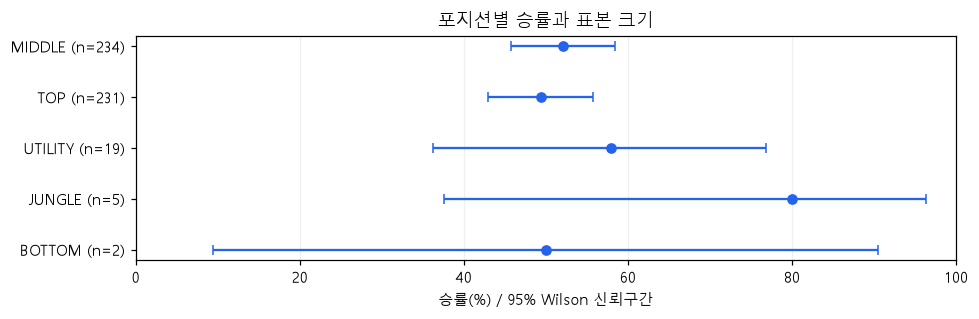

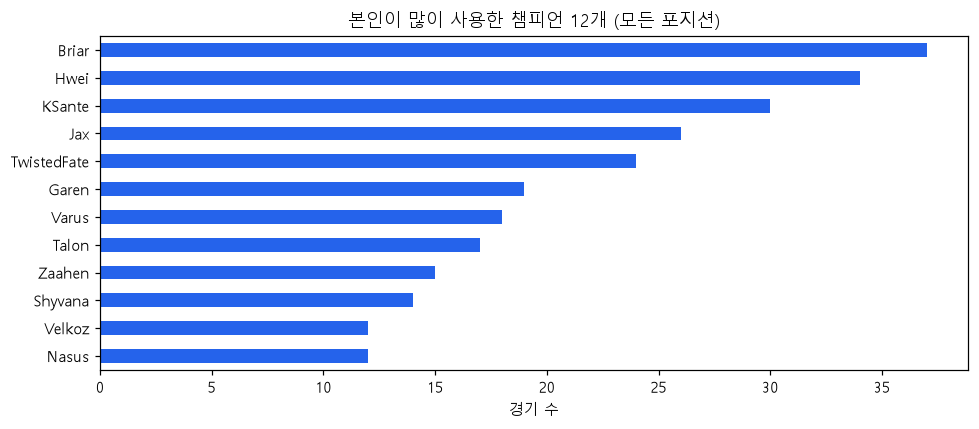

In [3]:
def summarize(data, keys):
    out = data.groupby(keys, dropna=False)['win'].agg(games='size', wins='sum').reset_index()
    out['losses'] = out['games'] - out['wins']
    n = out['games']
    p = out['wins'] / n
    z = 1.959963984540054
    center = (p + z*z/(2*n))/(1+z*z/n)
    half = z*np.sqrt(p*(1-p)/n + z*z/(4*n*n))/(1+z*z/n)
    out['win_rate'] = 100*p
    out['ci_low'] = (100*(center-half)).clip(lower=0)
    out['ci_high'] = (100*(center+half)).clip(upper=100)
    out['eligible'] = n >= MIN_GAMES
    return out

def show_table(table, limit=20):
    display(table.head(limit).round(1).rename(columns={
        'position':'내 포지션', 'champion':'내 챔피언', 'enemy':'적 챔피언', 'jungler':'아군 정글',
        'games':'경기 수', 'wins':'승', 'losses':'패', 'win_rate':'승률(%)',
        'ci_low':'95% 하한', 'ci_high':'95% 상한', 'baseline':'기준 승률(%)',
        'difference_pp':'차이(%p)', 'eligible':'10경기 이상'}))

def rate_plot(table, label, title, baseline=None):
    if table.empty:
        print(title + ': 최소 경기 수를 충족한 그룹이 없습니다.')
        return
    t = table.iloc[::-1]
    fig, ax = plt.subplots(figsize=(9, max(3, len(t)*0.45)))
    y = np.arange(len(t))
    ax.errorbar(t['win_rate'], y,
                xerr=np.vstack([t['win_rate']-t['ci_low'], t['ci_high']-t['win_rate']]),
                fmt='o', color='#2563eb', capsize=3)
    ax.set_yticks(y, [f'{name} (n={n})' for name,n in zip(t[label],t['games'])])
    if baseline is not None:
        ax.axvline(baseline, color='#888888', linestyle='--', label=f'포지션 평균 {baseline:.1f}%')
        ax.legend(loc='best')
    ax.set(xlim=(0,100), xlabel='승률(%) / 95% Wilson 신뢰구간', title=title)
    ax.grid(axis='x', alpha=.2)
    fig.tight_layout()
    plt.show()
    plt.close(fig)

position_stats = summarize(df, ['position'])
show_table(position_stats)
print(f"전체 {len(df)}경기: {int(df['win'].sum())}승 / 승률 {df['win'].mean()*100:.1f}%")
rate_plot(position_stats.sort_values('games', ascending=False), 'position', '포지션별 승률과 표본 크기')
fig, ax = plt.subplots(figsize=(9,4))
df['champion'].value_counts().head(12).sort_values().plot.barh(ax=ax, color='#2563eb')
ax.set(title='본인이 많이 사용한 챔피언 12개 (모든 포지션)', xlabel='경기 수', ylabel='')
fig.tight_layout(); plt.show(); plt.close(fig)
position_baseline = df.groupby('position')['win'].mean().mul(100).rename('baseline')


## 4. 질문 1 — 내가 어떤 챔피언을 골랐을 때 성적이 좋은가?

포지션을 섞으면 같은 챔피언이라도 역할이 달라진다. 포지션과 챔피언을 함께 묶고, 10경기 이상 그룹을 승률순으로 비교한다. 가장 높은 관측 승률이 미래의 최적 픽을 의미하지는 않는다.

### TOP

,내 포지션,내 챔피언,경기 수,승,패,승률(%),95% 하한,95% 상한,10경기 이상,기준 승률(%),차이(%p)
67,TOP,Jax,26,17,9,65.4,46.2,80.6,True,49.4,16.0
63,TOP,Garen,19,11,8,57.9,36.3,76.9,True,49.4,8.5
69,TOP,KSante,30,16,14,53.3,36.1,69.8,True,49.4,4.0
87,TOP,Shyvana,14,6,8,42.9,21.4,67.4,True,49.4,-6.5
103,TOP,Zaahen,15,6,9,40.0,19.8,64.3,True,49.4,-9.4
78,TOP,Nasus,10,3,7,30.0,10.8,60.3,True,49.4,-19.4


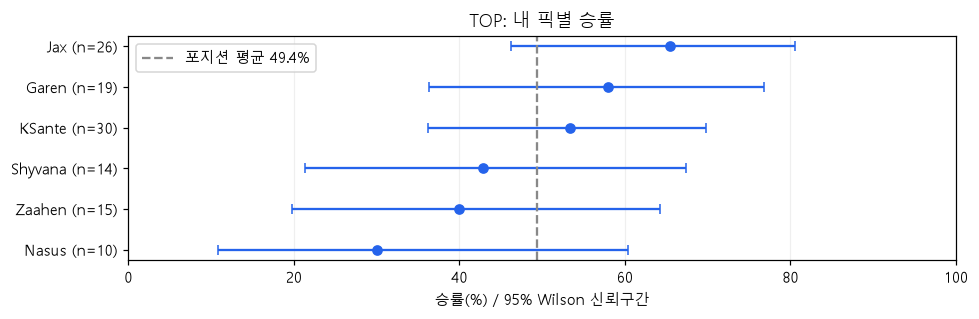

JUNGLE: 10경기 이상 챔피언 없음


### MIDDLE

,내 포지션,내 챔피언,경기 수,승,패,승률(%),95% 하한,95% 상한,10경기 이상,기준 승률(%),차이(%p)
39,MIDDLE,Varus,15,10,5,66.7,41.7,84.8,True,52.1,14.5
41,MIDDLE,Velkoz,12,8,4,66.7,39.1,86.2,True,52.1,14.5
38,MIDDLE,TwistedFate,24,14,10,58.3,38.8,75.5,True,52.1,6.2
36,MIDDLE,Talon,16,8,8,50.0,28.0,72.0,True,52.1,-2.1
13,MIDDLE,Briar,31,15,16,48.4,32.0,65.2,True,52.1,-3.7
20,MIDDLE,Hwei,31,15,16,48.4,32.0,65.2,True,52.1,-3.7


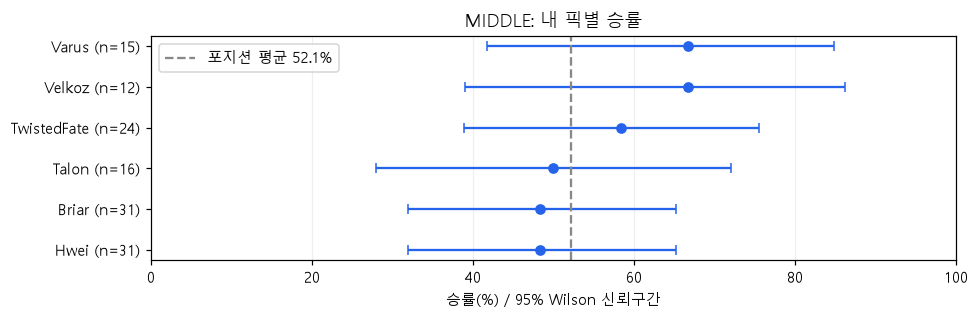

BOTTOM: 10경기 이상 챔피언 없음
UTILITY: 10경기 이상 챔피언 없음


In [4]:
pick_stats = summarize(df, ['position','champion']).merge(position_baseline, on='position')
pick_stats['difference_pp'] = pick_stats['win_rate'] - pick_stats['baseline']
for role in POSITIONS:
    ranked = pick_stats.query('position == @role and eligible').sort_values(['win_rate','games'], ascending=False)
    if ranked.empty:
        print(f'{role}: 10경기 이상 챔피언 없음')
        continue
    display(Markdown(f'### {role}'))
    show_table(ranked)
    rate_plot(ranked.head(10), 'champion', f'{role}: 내 픽별 승률', position_baseline[role])


## 5. 질문 2 — 어떤 상대를 만났을 때 성적이 낮은가?

두 가지 질문을 구분한다.
- **맞라인 상대:** 본인과 같은 포지션의 적 챔피언. 포지션이 누락되거나 중복된 경기는 이 분석에서 제외한다. 포지션 필드는 실제 라인 스왑까지 보장하지 않는다.
- **적팀 전체:** 적팀 5명 각각에 대해 포함 경기 승률을 계산한다. 한 경기가 여러 챔피언 그룹에 들어가므로 그룹들은 서로 독립이 아니며 경기 수를 합산해서는 안 된다.

결과는 경기 승률이며 라인전 승률이 아니다. 내 픽을 고정한 추가 비교 없이 상성으로 단정하지 않는다.

맞라인 분석: 491경기 / 제외 0경기


### TOP — 맞라인 상대: 낮은 승률순

,내 포지션,적 챔피언,경기 수,승,패,승률(%),95% 하한,95% 상한,10경기 이상,기준 승률(%),차이(%p)
79,TOP,Jax,10,5,5,50.0,23.7,76.3,True,49.4,0.6
93,TOP,Malphite,12,7,5,58.3,32.0,80.7,True,49.4,9.0
128,TOP,Yone,10,6,4,60.0,31.3,83.2,True,49.4,10.6


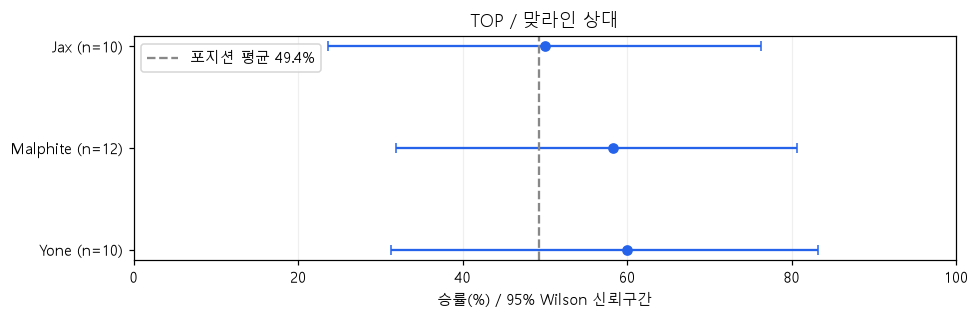

### MIDDLE — 맞라인 상대: 낮은 승률순

,내 포지션,적 챔피언,경기 수,승,패,승률(%),95% 하한,95% 상한,10경기 이상,기준 승률(%),차이(%p)
7,MIDDLE,Ahri,16,3,13,18.8,6.6,43.0,True,52.1,-33.4
56,MIDDLE,Zed,11,3,8,27.3,9.7,56.6,True,52.1,-24.9
41,MIDDLE,Sylas,10,3,7,30.0,10.8,60.3,True,52.1,-22.1
45,MIDDLE,TwistedFate,14,7,7,50.0,26.8,73.2,True,52.1,-2.1
50,MIDDLE,Viktor,19,11,8,57.9,36.3,76.9,True,52.1,5.8
54,MIDDLE,Yasuo,11,10,1,90.9,62.3,98.4,True,52.1,38.8


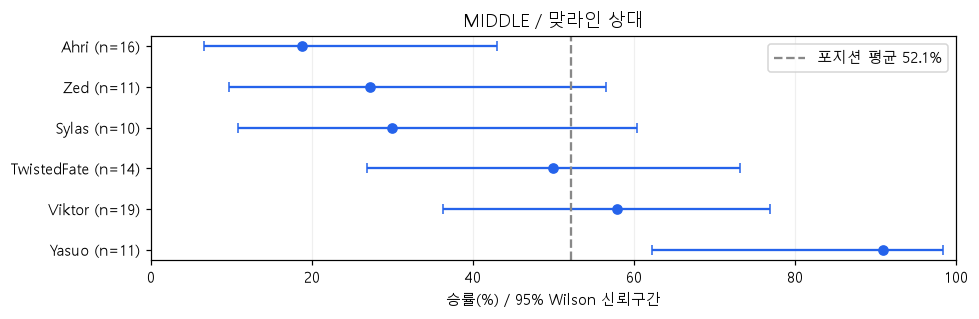

### TOP — 적팀 전체: 낮은 승률순

,내 포지션,적 챔피언,경기 수,승,패,승률(%),95% 하한,95% 상한,10경기 이상,기준 승률(%),차이(%p)
256,TOP,Karma,17,5,12,29.4,13.3,53.1,True,49.4,-19.9
285,TOP,Naafiri,13,4,9,30.8,12.7,57.6,True,49.4,-18.6
254,TOP,Kaisa,22,7,15,31.8,16.4,52.7,True,49.4,-17.5
336,TOP,TwistedFate,12,4,8,33.3,13.8,60.9,True,49.4,-16.0
288,TOP,Nautilus,19,7,12,36.8,19.1,59.0,True,49.4,-12.5
246,TOP,Irelia,10,4,6,40.0,16.8,68.7,True,49.4,-9.4
320,TOP,Sion,10,4,6,40.0,16.8,68.7,True,49.4,-9.4
339,TOP,Varus,10,4,6,40.0,16.8,68.7,True,49.4,-9.4
346,TOP,Viktor,10,4,6,40.0,16.8,68.7,True,49.4,-9.4
202,TOP,Ahri,22,9,13,40.9,23.3,61.3,True,49.4,-8.4


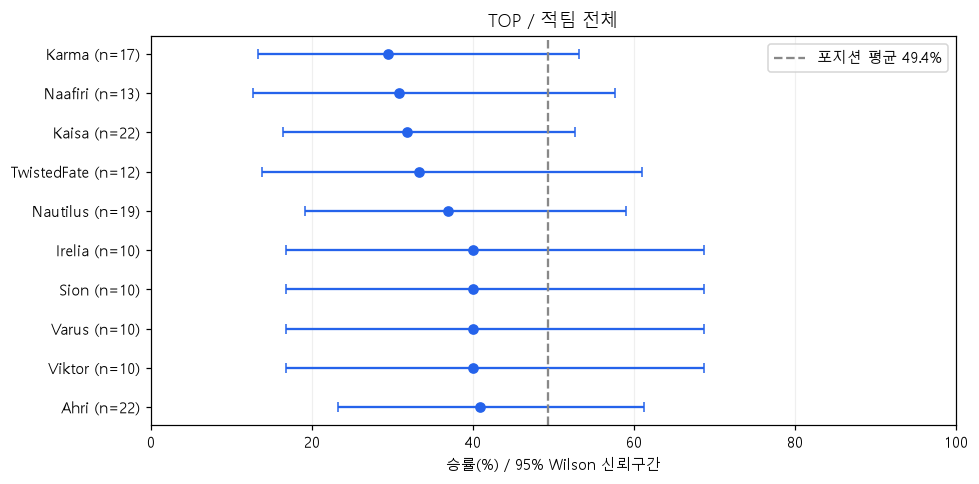

### MIDDLE — 적팀 전체: 낮은 승률순

,내 포지션,적 챔피언,경기 수,승,패,승률(%),95% 하한,95% 상한,10경기 이상,기준 승률(%),차이(%p)
34,MIDDLE,Ahri,16,3,13,18.8,6.6,43.0,True,52.1,-33.4
53,MIDDLE,Caitlyn,20,5,15,25.0,11.2,46.9,True,52.1,-27.1
195,MIDDLE,Zed,17,5,12,29.4,13.3,53.1,True,52.1,-22.7
108,MIDDLE,Malphite,14,5,9,35.7,16.3,61.2,True,52.1,-16.4
118,MIDDLE,Naafiri,11,4,7,36.4,15.2,64.6,True,52.1,-15.8
164,MIDDLE,Talon,15,6,9,40.0,19.8,64.3,True,52.1,-12.1
33,MIDDLE,Aatrox,10,4,6,40.0,16.8,68.7,True,52.1,-12.1
112,MIDDLE,Mel,10,4,6,40.0,16.8,68.7,True,52.1,-12.1
189,MIDDLE,Yone,19,8,11,42.1,23.1,63.7,True,52.1,-10.0
187,MIDDLE,XinZhao,14,6,8,42.9,21.4,67.4,True,52.1,-9.3


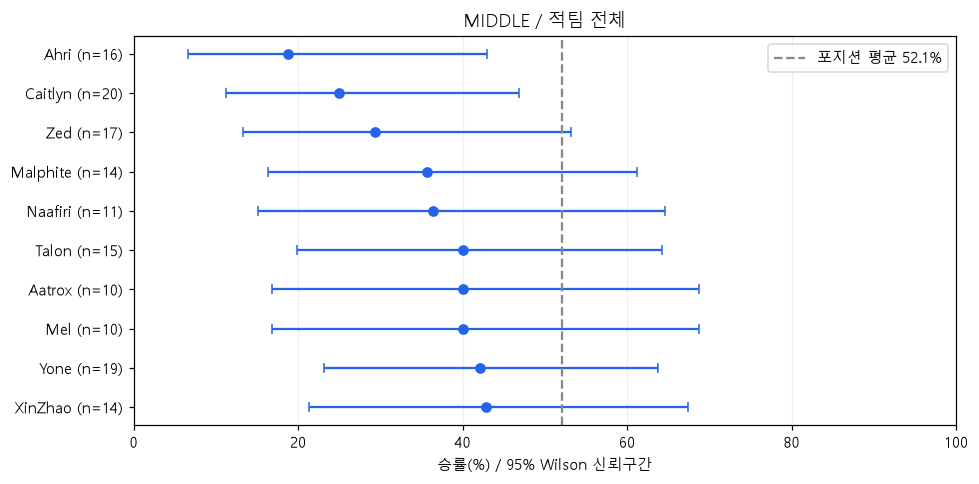

In [5]:
enemy_parts = []
for i in range(1,6):
    part = df[['match_id','position','champion','win',f'enemy_{i}_champion',f'enemy_{i}_position']].rename(
        columns={f'enemy_{i}_champion':'enemy', f'enemy_{i}_position':'enemy_position'})
    enemy_parts.append(part)
enemies = pd.concat(enemy_parts, ignore_index=True).dropna(subset=['enemy'])
same_role = enemies.loc[enemies['position'].eq(enemies['enemy_position'])].copy()
counts = same_role.groupby('match_id').size()
same_role = same_role.loc[same_role['match_id'].isin(counts[counts.eq(1)].index)]
print(f'맞라인 분석: {same_role.match_id.nunique()}경기 / 제외 {len(df)-same_role.match_id.nunique()}경기')
all_enemies = enemies.drop_duplicates(['match_id','enemy'])
matchup_stats = summarize(same_role, ['position','enemy'])
enemy_stats = summarize(all_enemies, ['position','enemy'])
for title, table, population in [('맞라인 상대', matchup_stats, same_role), ('적팀 전체', enemy_stats, all_enemies)]:
    base = population.drop_duplicates('match_id').groupby('position')['win'].mean().mul(100).rename('baseline')
    table = table.merge(base, on='position')
    table['difference_pp'] = table['win_rate'] - table['baseline']
    for role in ['TOP','MIDDLE']:
        ranked = table.query('position == @role and eligible').sort_values(['win_rate','games'], ascending=[True,False]).head(10)
        display(Markdown(f'### {role} — {title}: 낮은 승률순'))
        show_table(ranked)
        rate_plot(ranked, 'enemy', f'{role} / {title}', base.get(role))


## 6. 질문 3 — 어떤 아군 정글과 함께했을 때 성적이 좋은가?

`ally_2`를 정글로 가정하지 않고 모든 아군 슬롯에서 `JUNGLE`을 찾는다. 본인이 정글인 경기는 제외한다.

먼저 본인 포지션별 아군 정글 성적을 보고, 이후 **내 포지션 + 내 챔피언 + 아군 정글**로 좁힌다. 조합의 기준 승률은 정글 정보가 유효한 경기에서 같은 내 포지션·챔피언의 평균이다. 조합별 비교에서는 경기 수가 급격히 줄어드는 점을 확인한다.

정글 조합 분석 486경기 / 본인 정글 5경기 제외
아군 정글 누락·중복 제외: 0


### TOP — 아군 정글별

,내 포지션,아군 정글,경기 수,승,패,승률(%),95% 하한,95% 상한,10경기 이상
73,TOP,LeeSin,21,14,7,66.7,45.4,82.8,True
91,TOP,Sylas,11,7,4,63.6,35.4,84.8,True
65,TOP,Graves,22,12,10,54.5,34.7,73.1,True
69,TOP,Jayce,24,12,12,50.0,31.4,68.6,True
53,TOP,Ambessa,12,5,7,41.7,19.3,68.0,True
98,TOP,XinZhao,12,5,7,41.7,19.3,68.0,True
67,TOP,JarvanIV,12,4,8,33.3,13.8,60.9,True


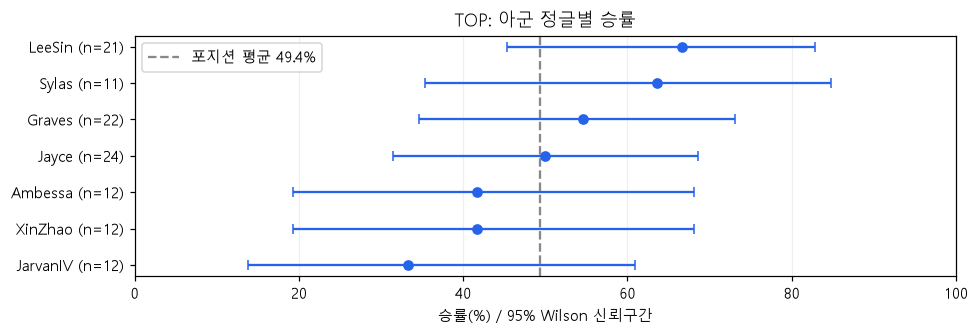

### MIDDLE — 아군 정글별

,내 포지션,아군 정글,경기 수,승,패,승률(%),95% 하한,95% 상한,10경기 이상
16,MIDDLE,JarvanIV,14,9,5,64.3,38.8,83.7,True
21,MIDDLE,LeeSin,23,14,9,60.9,40.8,77.8,True
13,MIDDLE,Graves,30,16,14,53.3,36.1,69.8,True
46,MIDDLE,Vi,17,9,8,52.9,31.0,73.8,True
27,MIDDLE,Naafiri,10,4,6,40.0,16.8,68.7,True
17,MIDDLE,Jayce,21,6,15,28.6,13.8,50.0,True


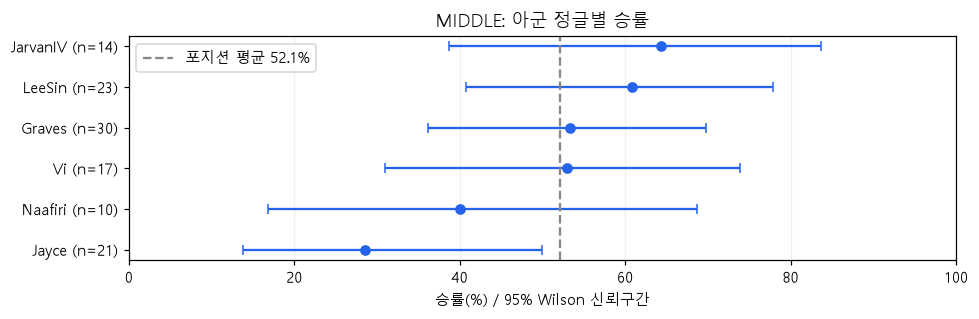

### 내 챔피언 + 아군 정글: 주요 비교

전체 399개 조합 중 10경기 이상: 0개
주요 비교 기준을 충족한 조합이 없어 우수 조합을 선정하지 않습니다.


### 참고: 경기 수가 많은 조합 (10경기 미만, 추천 순위 아님)

,내 포지션,내 챔피언,아군 정글,경기 수,승,패,승률(%),95% 하한,95% 상한,10경기 이상,기준 승률(%),차이(%p)
24,MIDDLE,Briar,LeeSin,8,4,4,50.0,21.5,78.5,False,48.4,1.6
251,TOP,Jax,Jayce,6,5,1,83.3,43.6,97.0,False,65.4,17.9
56,MIDDLE,Hwei,Graves,6,3,3,50.0,18.8,81.2,False,48.4,1.6
123,MIDDLE,TwistedFate,Graves,4,3,1,75.0,30.1,95.4,False,58.3,16.7
269,TOP,KSante,Graves,4,3,1,75.0,30.1,95.4,False,53.3,21.7
278,TOP,KSante,Nocturne,4,2,2,50.0,15.0,85.0,False,53.3,-3.3
57,MIDDLE,Hwei,Jayce,4,0,4,0.0,0.0,49.0,False,48.4,-48.4
66,MIDDLE,Hwei,Talon,3,3,0,100.0,43.9,100.0,False,48.4,51.6
249,TOP,Jax,Graves,3,3,0,100.0,43.9,100.0,False,65.4,34.6
274,TOP,KSante,LeeSin,3,3,0,100.0,43.9,100.0,False,53.3,46.7


In [6]:
ally_parts = []
for i in range(1,5):
    part = df.loc[df[f'ally_{i}_position'].eq('JUNGLE') & df['position'].ne('JUNGLE'),
                  ['match_id','position','champion','win',f'ally_{i}_champion']].rename(columns={f'ally_{i}_champion':'jungler'})
    ally_parts.append(part)
jungle = pd.concat(ally_parts, ignore_index=True).dropna(subset=['jungler'])
counts = jungle.groupby('match_id').size()
jungle = jungle.loc[jungle['match_id'].isin(counts[counts.eq(1)].index)]
print(f'정글 조합 분석 {len(jungle)}경기 / 본인 정글 {df.position.eq("JUNGLE").sum()}경기 제외')
print('아군 정글 누락·중복 제외:', df.position.ne('JUNGLE').sum()-len(jungle))
jungle_stats = summarize(jungle, ['position','jungler'])
for role in ['TOP','MIDDLE']:
    ranked = jungle_stats.query('position == @role and eligible').sort_values(['win_rate','games'],ascending=False).head(10)
    display(Markdown(f'### {role} — 아군 정글별'))
    show_table(ranked)
    base = jungle.loc[jungle.position.eq(role),'win'].mean()*100
    rate_plot(ranked, 'jungler', f'{role}: 아군 정글별 승률', base)

combo_stats = summarize(jungle, ['position','champion','jungler'])
combo_base = jungle.groupby(['position','champion'])['win'].mean().mul(100).rename('baseline')
combo_stats = combo_stats.merge(combo_base, on=['position','champion'])
combo_stats['difference_pp'] = combo_stats['win_rate'] - combo_stats['baseline']
qualified_combos = combo_stats.loc[combo_stats.eligible].sort_values(['win_rate','games'],ascending=False)
display(Markdown('### 내 챔피언 + 아군 정글: 주요 비교'))
print(f'전체 {len(combo_stats)}개 조합 중 10경기 이상: {len(qualified_combos)}개')
if qualified_combos.empty:
    print('주요 비교 기준을 충족한 조합이 없어 우수 조합을 선정하지 않습니다.')
else:
    show_table(qualified_combos)
display(Markdown('### 참고: 경기 수가 많은 조합 (10경기 미만, 추천 순위 아님)'))
show_table(combo_stats.loc[~combo_stats.eligible].sort_values(['games','win_rate'],ascending=False),10)


## 7. 결과 요약과 해석

아래 문장은 현재 입력 데이터와 분석 기준에 따라 자동으로 갱신된다. 주요 비교 대상이 없는 경우 결론을 강제로 만들지 않는다.

In [7]:
findings = []
for role in ['TOP','MIDDLE']:
    subset = pick_stats.query('position == @role and eligible').sort_values(['win_rate','games'],ascending=False)
    if not subset.empty:
        best = subset.iloc[0]
        findings.append(f"- **{role} 내 픽:** {best.champion}, {int(best.games)}경기 {int(best.wins)}승, 승률 {best.win_rate:.1f}%. 같은 포지션 평균 대비 {best.difference_pp:+.1f}%p.")
    subset = enemy_stats.query('position == @role and eligible').sort_values(['win_rate','games'],ascending=[True,False])
    if not subset.empty:
        worst = subset.iloc[0]
        findings.append(f"- **{role} 적팀 전체:** {worst.enemy} 포함 경기의 승률이 비교 대상 중 가장 낮음 ({int(worst.games)}경기, {worst.win_rate:.1f}%).")
findings.append(f'- **아군 조합:** 최소 {MIN_GAMES}경기를 충족한 내 픽·정글 조합은 {len(qualified_combos)}개. 조합 추천 가능 여부는 표본 수에 따라 판단한다.')
display(Markdown('\n'.join(findings)))
# 결과 정합성 확인: 집계 승수·경기수가 실제 분석 모집단과 일치해야 한다.
assert pick_stats.games.sum() == len(df)
assert pick_stats.wins.sum() == df.win.sum()
assert combo_stats.games.sum() == len(jungle)
assert all_enemies.groupby('match_id').size().le(5).all()
assert ((pick_stats.ci_low <= pick_stats.win_rate + 1e-10) & (pick_stats.win_rate <= pick_stats.ci_high + 1e-10)).all()
print('집계 정합성 검증 완료')


- **TOP 내 픽:** Jax, 26경기 17승, 승률 65.4%. 같은 포지션 평균 대비 +16.0%p.
- **TOP 적팀 전체:** Karma 포함 경기의 승률이 비교 대상 중 가장 낮음 (17경기, 29.4%).
- **MIDDLE 내 픽:** Varus, 15경기 10승, 승률 66.7%. 같은 포지션 평균 대비 +14.5%p.
- **MIDDLE 적팀 전체:** Ahri 포함 경기의 승률이 비교 대상 중 가장 낮음 (16경기, 18.8%).
- **아군 조합:** 최소 10경기를 충족한 내 픽·정글 조합은 0개. 조합 추천 가능 여부는 표본 수에 따라 판단한다.

집계 정합성 검증 완료


## 8. 한계와 다음 분석

### 해석의 한계
1. **개인 기록의 선택 편향:** 한 계정의 최근 경기이며 전체 플레이어로 일반화할 수 없다.
2. **작은 표본과 다중 비교:** 많은 챔피언 중 극단적인 승률이 우연히 나올 수 있다. 10경기는 표시 기준일 뿐 신뢰성을 보장하지 않는다.
3. **교란 요인:** 패치, 숙련도, 상대 실력, 듀오, 나머지 팀 조합 등을 통제하지 않았다. 관측 승률 차이는 조합의 인과 효과가 아니다.
4. **기간 효과:** 여러 패치를 합친 결과다. 패치를 더 세분화하면 표본이 줄어든다.
5. **승률과 라인전의 차이:** 경기 승패만으로 라인전 우열을 알 수 없다. 종료 시점 KDA·골드는 결과에 영향을 받으므로 픽 시점 예측 변수로 사용하면 정보 누출이 생긴다.
6. **다시하기 분류:** 3분 기준은 대리 지표다. 향후 수집 시 조기 종료 필드를 추가해 기준을 개선한다.

### 다음 행동
- 승률이 낮은 상대 경기의 리플레이를 복기해 반복되는 문제를 찾는다.
- 발견한 픽·조합 후보를 미리 정하고, **이후 새로 수집한 경기**에서 같은 분석 기준으로 재검증한다. 현재 자료로 기준을 바꿔가며 성과를 높이지 않는다.
- 타임라인을 수집하면 10분·15분 상대 라이너 대비 골드·CS 차이로 라인전 분석을 확장한다.

### 포트폴리오에서 전달할 메시지
API 데이터 수집 → 품질 검증 → 비교 단위와 기준 정의 → 불확실성을 포함한 탐색 → 표본 부족을 인정한 결론으로 이어지는 분석 과정을 제시한다. 이 노트북은 확정적인 픽 추천 모델이 아니라 **개인 경기 기록에서 검증할 가설을 찾는 분석**이다.
